# Different Theta Conditions: Clean Theta, No Theta, Scrambled Theta

In this notebook, we will look at the different theta conditions that will be implemented in the model. The three theta conditions that will be set up and tested are (1) clean theta, (2) no theta, and (3) scrambled theta.

### *Pure Spatial Rate Code*
To provide some background on the model, each cell (i.e. basis feature) in this model has their own spatial rate code, which is defined by a thresholded Gaussian distribution with mean $x_j$ and $sd =1m$. The peak firing rate is 5Hz at the centre of the field ($x_j$) and 0 outside of the field. The firing rate is described by the following formula:

$f_j^x(x(t))= Gaussian(x_j,\sigma) -c$ if $||x(t)-x_j< 1m||$  and otherwise $0$

Or written in a more comprehensive and hence complex manner:

\[
\begin{aligned}
f_j^x(x(t)) &= \frac{F}{1 - e^{- \frac{1}{2}}} \left[ e^{-\frac{\|x(t) - x_j\|^2}{2 \sigma^2}} - e^{- \frac{1}{2}} \right]_+ \\
\end{aligned}
\]

where F is the peak firing rate at the centre with $F=5Hz$ and $\sigma=1m$ is the threshold radius, and $x(t)$ is the location of the agent at time $t$. 
So the formula above can be used to calculate the actual spatial firing rate (the pure spatial rate code) of a basis feature j when the agent is at location $x$ at time $t$.

### *Implementation of Phase Precession & Theta Modulation*
Phase precession is implemented via a phase precession factor by which the pure spatial firing rate is multiplied. This factor is described by the following formula:

\[
\begin{aligned}
f_j^\theta(\Phi_\theta(t)) = 2\pi f_{VM}(\Phi_\theta(t)|\Phi_j^*(x),k)  \\
\end{aligned}
\]

The term on the left is only large, if the current theta phase matches or is very close to the preferred theta phase. $2\pi$ is for normalisation of the function $f_{VM}(x|\mu,k)$ where $x∈(0,2)$ on a circle is the current theta phase, $\mu$ is the mean of the preferred theta phase at position $x$, and $k$ is the spread parameter of the vonMises distribution. In a way the vonMises distribution can be thought of as a normal distribution but in a circle with mean  and $sd = k$.

The current theta phase is described by the following formula: 

$\Phi_\theta(t) = 2\pi v_\theta t$   $(mod 2\pi)$

where $v_\theta =$ frequency of theta (by default set to $10Hz$) , and $\Phi_\theta(t) ∈ [0, 2\pi]$.

The preferred that phase is given by the next formula:

$\Phi_j^*(x(t))=\pi+\beta\pi d_j(x(t))$

where $d_j(x(t))∈ [-1,1]$  tracks how far through the field the agent has travelled, which is measured in units of $\sigma$. This can be precisely formulated via formula (11) in the methods section of George et al. (2023), which I will not fomat here because formatting formulas in markdown is not it respectfully. 

The fact that the pure spatial rate code firing rate is multiplied by the theta phase precession factor, means that the basis feature only fires (i.e. has a higher probability of generating a spike) if the current theta phase matches the cell’s preferred theta phase and this preferred theta phase is earlier and earlier in the theta cycle as the agent traverses the cell’s receptive field (RF). Consequently, this also means that the general spatial firing pattern only emerges with the agent crossing the receptive field multiple times, because during a single crossing of the RF the agent might be at the centre of the field, while the preferred phase might not match the current phase of global theta at $x(t)$, meaning that no spikes are being generated (or that there is a lower probability of spikes actually being generated). 
Whether or not a spike is being generated is evaluated/calculated for each time bin, i.e. the time window that discretises time. For a smaller time window this is calculated more frequently accordingly and the spikes are more precise, because if a spike is generated, that spike is placed randomly within that time window. In the model at hand, time is discretised with dt= 0.005
Across one field, the cell precesses by half a theta cycle (=0.5). This can be illustrated by actually calculating the preferred phase for some example values by hand with the formula above, but due to markdown being markdown, I won't add these calculations here at this point (maybe add them later).

In conclusion, the final firing rate is given by:

$f_j(x(t))=f_j^x(x)f_j^\theta(x(t))$

These final firing rates are converted into the previously mentioned spike trains using an inhomogeneous Poisson process, meaning that given the firing rate, there is a certain stochastic probability that a spike will occur or not. The resulting spikes, their timing and order is what drives the learning process of the weights in the SR matrix.

Clean theta is implemented as follows: 
In the model there is a global theta oscillation defined as:  

$\Phi_\theta(t) = 2\pi v_\theta t$   $(mod 2\pi)$

where $v_\theta =$ frequency of theta, and $\Phi_\theta(t) ∈ [0, 2\pi]$.

This global theta oscillation resets after each cycle

## Theta Conditions

### *Clean Theta*
As mentioned above the global theta oscillation is given by 

$\Phi_\theta(t) = 2\pi v_\theta t$   $(mod 2\pi)$

where $v_\theta =$ frequency of theta, and $\Phi_\theta(t) ∈ [0, 2\pi]$.

This global theta oscillation resets after each cycle, meaning it is rhytmic and predictable and can be easily reconstructed retrospectively for each moment of time $t$, as long as the phase of theta at $t=0$ is known, which is the case in this model. 
Theta modulation and phase precession occurs as described above, where the preferred phase moves to earlier and earlier phases of the cycle as the agent traverses the field, leading to a higher probability of spikes occurring in that window when the global osicllation phase at time $t$ matches the preferred phase at time $t$. 

### *No Theta*
In the "no theta" condition there is no modulation of the pure spatial rate code by a theta modulation factor. This means that the weights in the weight matrix are still learned via the STDP learning rule, but this learning rule uses the pure spatial rate code which is then simply
 
$f_j(x(t))=f_j^x(x)$

In conclusion, and to put it simply, the weights in the matrix are learned using the pure spatial rate code; no temporal modulation via theta takes place. 

### *Scrambled Theta*
In the scrambled theta condition there is no rhytmic and predictable global oscillation anymore, instead the global oscillation was generated as a circular Brownian motion (random walk on the unit (i.e $2\pi$) circle). This disrupts phase precession, while the pure spatial firing patterns, i.e. the spatial rate code, is preserved. This approach leads to phase diffusion rather than periodic oscillation with superimposed noise, matching the biophysical disruption observed in optogenetic frequency scrambling studies (e.g. Etter et al., 2023). The phase of the scrambled global oscillation evolved incrementally according to the following stochastic differential equation:

$$\phi_\theta^{scr}(t + \Delta t) = \left[ \phi_\theta^{scr}(t) + 2\pi \nu_\theta \Delta t + \xi(t) + \eta(t) \right] \mod 2\pi$$

where:
- $\nu_\theta = 10$ Hz (nominal theta frequency)
- $\Delta t = 1$ ms (simulation timestep)
- $\xi(t) \sim \mathcal{N}(0, \sigma_{scramble} = 0.5)$ radian (low-frequency random walk noise)
- $\eta(t) \sim \mathcal{N}(0, \sigma_{HF} = 0.5)$ radians (high-frequency jitter noise)
- $\mod 2\pi$ constrains $\phi_\theta^{scr}(t) \in [0, 2\pi)$ to still allow for calculation of the modulated firing rate with the vonMises distribution which expects a phase on the unit circle

((The total step variance was $\sigma_{total}^2 = 0.5^2 + 0.5^2 = 0.5$ $rad^2$ (RMS step $\approx 41^\circ$ per ms). Over one theta cycle ($\sim$100 ms), cumulative phase diffusion ($\sigma \approx 8$ rad) exceeded one full cycle, yielding a stationary uniform distribution $\phi_\theta^{scr}(t) \sim \text{Uniform}[0, 2\pi)$.)) -> depends on values of scramble_strength and hf_strength

**Continuity with clean theta:** When noise was zero (i.e. $\sigma_{scramble} = \sigma_{HF} = 0$), the update rule of $\phi_\theta^{scr}(t + \Delta t)$ produced identical phase progression to clean theta, as the recursive summation of deterministic drift terms $2\pi \nu_\theta \Delta t$ reconstructed the closed-form clean 10Hz wave form. Thsi means that the strength or amount of scrambling can be controlled via the two parameters $\xi(t)=scramblingStrength$ (low frequency noise) and $\eta(t)=hfStrength$ (high frequency noise). 

Within the code, phase updates occurred within the scrambled condition's theta modulation function (called once per timestep during STDP learning for the scrambled condition only), with complete phase history stored for local field potential reconstruction. Place cell preferred phases remained position-dependent ($\phi_j^*(x) = \pi + \beta \pi d_j$), meaning that the cells themselves still have their preferred theta phase and could theoretically "phase precess", but that the "issue" or the location of experimental manipulation in this simulation really is the pace maker (medial septum (MS) in real animals), reflected in scrambling the global oscillation, while the properties of the cells themselves (spatial rate code & place fields and aility to phase precess) remain intact. 

In conclusion, the scrambled condition is implemented in the way that the properties of the basis features are preserved, while the global oscillation is scrambled (non-rhytmic, unpredictable and noisy) reflected by a power spectrum that resembles white noise with no clear peak at any frequency. This parallels experimental studies in which the MS as the pace maker of global hippocampal theta was the target for scrambling via for example optogenetics, while place cells were simply exposed to the consequences of this manipulation. In the model, the basis features are still "trying" to phase precess, but since the global theta phases are random, the match with the cells' preferred phases is random, which disrupts their sequential and predictive firing patterns that are necessary for generating theta sweeps.  
 

In [1]:
# Imports
import sys # for path management
sys.path.insert(0, "/Users/liviastein/STDP_Theta-1/STDP-SR_scripts")  # Ensure current directory is in path
from MazeAgent_Script import *  # import all functions from MazeAgent_Script
import copy
import tomplotlib.tomplotlib as tpl

%load_ext autoreload
%autoreload 2

#for plotting in notebook
%matplotlib inline  

### Define Parameters, agent, visualiser

Setting parameters
Initialising
   making state/history dataframes
   initialising velocity, position and direction
   setting time/run counters
   initialising theta phases: clean and scrambled
   making the maze walls
   discretising position for later plotting
   handling undefined parameters
   initialising basis features for learning
   calculating state vector at all discretised positions


  0%|          | 0/10000 [00:00<?, ?it/s]

   initialising STDP weight matrix and traces
Adding 'theta scrambled' Condition
DONE


(<Figure size 4000x160 with 1 Axes>, <Axes: >)

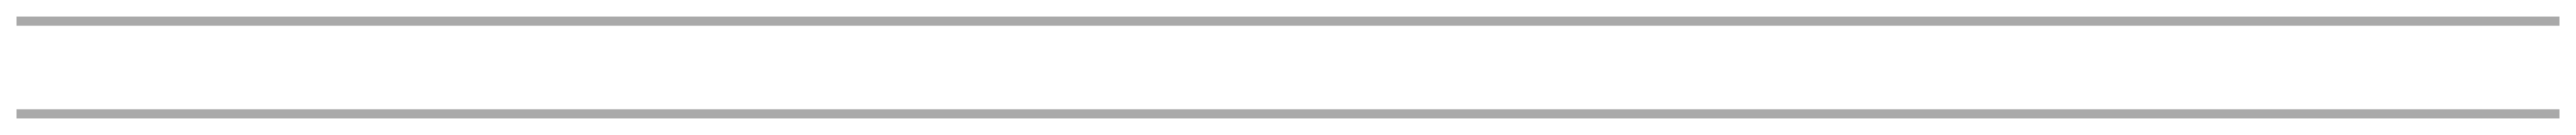

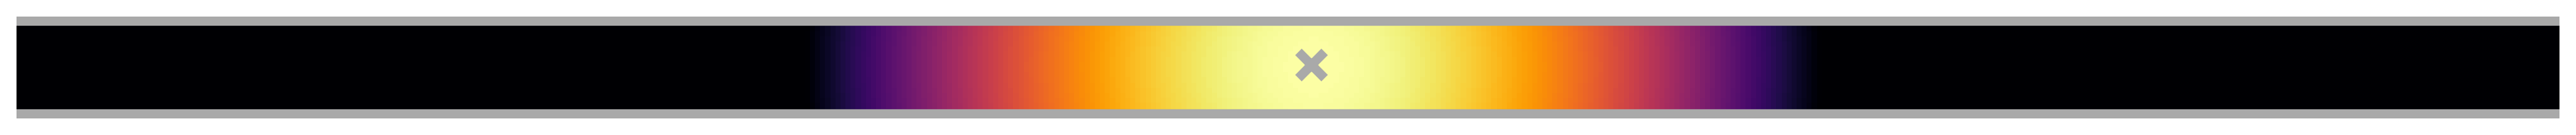

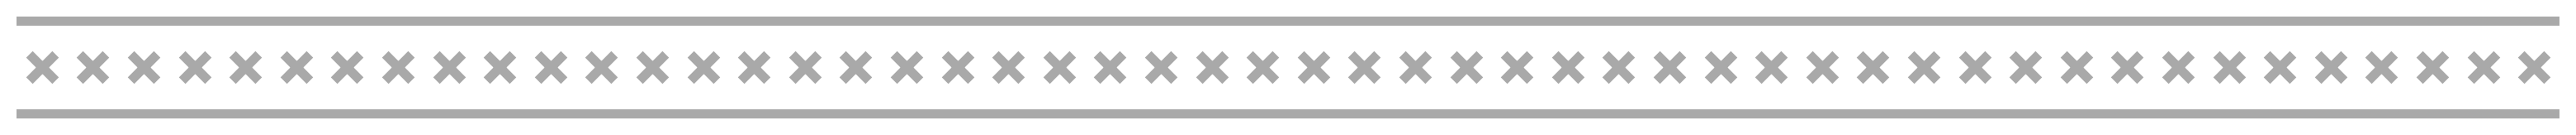

In [13]:
## Define parameters for maze and agent
# number of placeCells
N=50

# set x and y coordinates for place cell centres
xcen = np.linspace(0,5,N+1)[:-1] # we want to place N place cells evenly across the 5m length of the maze, so we create N+1 evenly spaced points and then take all but the last one (which is at 5m) to get the centres of the place cells.
xcen += (xcen[1] - xcen[0]) / 2 # we want the first place cell to be centred at 0.1m, so we shift all the centres by half the distance between them (i.e. the distance between the first centre and 0m) to get the final x coordinates of the place cell centres.
ycen = np.array([0.1]*N) # we want all the place cells to be centred at 0.1m in the y direction (i.e. 10cm from the south wall) so we set all the y coordinates of the place cell centres to 0.1m.
centres = np.vstack((xcen,ycen)).T # we combine the x and y coordinates into a single array of shape (N,2) where each row is the (x,y) coordinates of a place cell centre.

# set parameters for the MazeAgent class
params = {
           #Maze params 
          'mazeType'            : 'loop',  #type of maze, define in getMaze() function
          'stateType'           : 'gaussianThreshold', #feature on which to TD learn (onehot, gaussian, gaussianCS, circles, bump)
          'movementPolicy'      : 'windowsScreensaver',  #movement policy (raudies, random walk, windows screensaver)
          'roomSize'            : 5,          #maze size scaling parameter, metres
          'dt'                  : 0.005,       #simulation time disretisation (defualts to largest )
          'dx'                  : 0.01,       #space discretisation (for plotting, movement is continuous)
          'speedScale'          : 0.16,       #movement speed scale, metres/second
          'rotSpeedScale'       : None,       #rotational speed scale, radians/second
          'initPos'             : None,  #initial position [x0, y0], metres
          'initDir'             : None,      #initial direction, unit vector
          'nCells'              : N,       #how many features to use
          'centres'             : centres,       #array of receptive field positions. Overwrites nCells
          'sigma'               : 1,          #basis cell width scale (irrelevant for onehots)
          'doorsClosed'         : False,       #whether doors are opened or closed in multicompartment maze
          'reorderCells'        : True,       #whether to reorde the cell centres which have been provided
          'firingRateLookUp'    : False,      #use quantised lookup table for firing rates 
          'biasDoorCross'       : False,      #if True, in twoRoom maze door crossings are biased towards
          'biasWallFollow'      : True,       #if True, agent aligns to wall when gets too near.

          #TD params 
          'tau'                 : 4,          #TD decay time, seconds
          'TDdx'                : 0.1,       #rough distance between TD learning updates, metres 
          'alpha'               : 0.01,       #TD learning rate 
          'successorFeatureNorm': 100,        #linear scaling on successor feature definition found to improve learning stability
          'TDreg'               : 0.01,       #L2 regularisation 
          
          #STDP params
          'peakFiringRate'      : 5,          #peak firing rate of a cell (middle of place field,preferred theta phase)
          'tau_STDP_plus'       : 20e-3,      #pre trace decay time
          'tau_STDP_minus'      : 40e-3,      #post trace decay time
          'a_STDP'              : -0.4,       #pre-before-post potentiation factor (post-before-pre = 1) 
          'eta'                 : 0.01,       #STDP learning rate
          'baselineFiringRate'  : 0,          #baseline firing rate for cells 
          'use_full_STDP_rule'  : True,      #whether to use full STDP rule     
          'online_mapping'      : 'identity',  #how to map CA3-->CA1 during learning
          'rownorm'             : False,

          #Theta precession params
          'thetaFreq'           : 10,         #theta frequency
          'precessFraction'     : 0.5,        #fraction of 2pi the prefered phase moves through
          'kappa'               : 1,          # von mises spread parameter
          
          #Theta scrambling params (Livi addition)
          'scramble_strength'    : 1.0,        # strength of theta phase scrambling 
          'hf_strength'          : 1.0,        # strength of high frequency jitter added to scrambled theta phase

}

agent_scr = MazeAgent(params)
plotter = Visualiser(agent_scr)
agent_scr.toggleDoors(params['doorsClosed'])

plotter.plotMazeStructure() # plot maze structure to check it's correct before starting simulation
plotter.plotReceptiveField(25) # plot receptive field of place cell 25 in the middel of loop
plotter.plotFeatureCells(centresOnly=True, textlabel=False) # plots centres of the place cells in maze (no heatmap)


### Simulation Loop

  0%|          | 0/360000 [00:00<?, ?it/s]

Calculating place and grid cells


(<Figure size 400x400 with 2 Axes>,
 <Axes: title={'center': "TD matrix 'M' after 30min of TD learning"}>,
 <Axes: >)

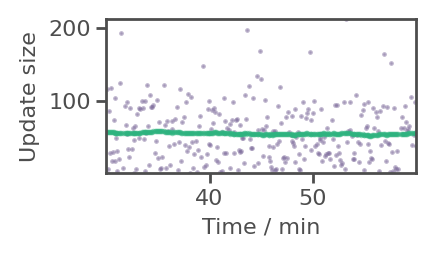

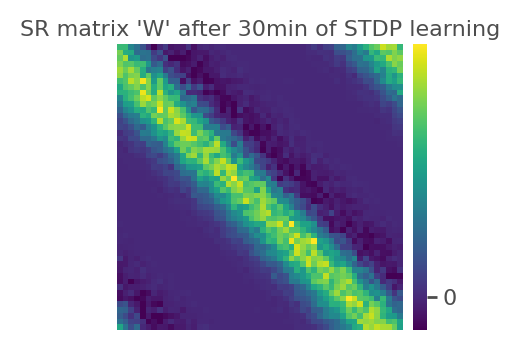

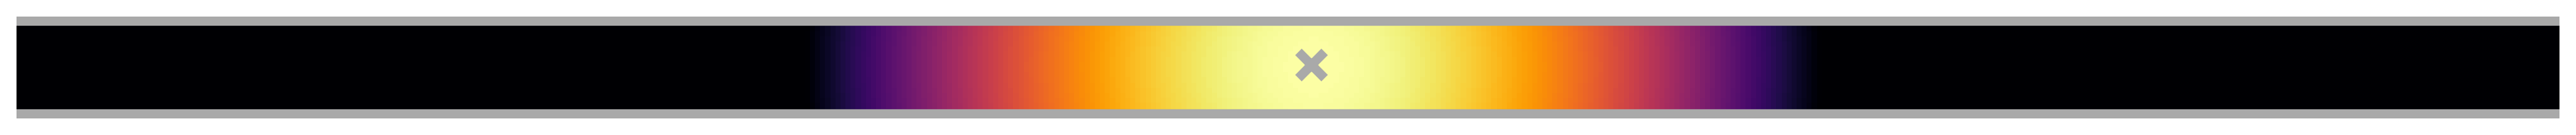

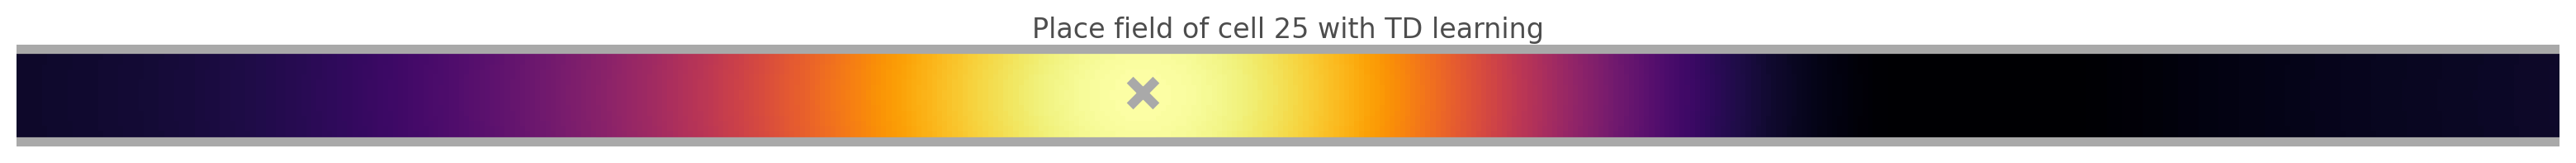

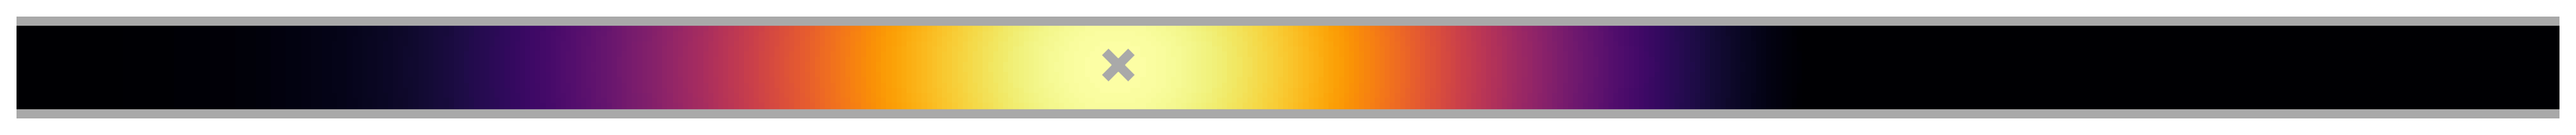

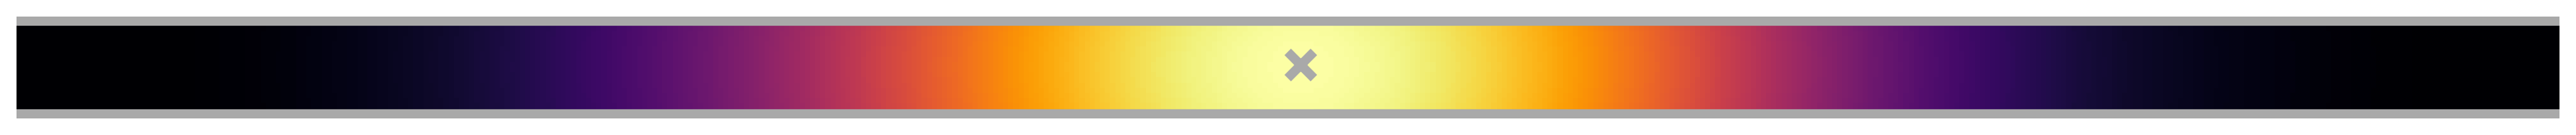

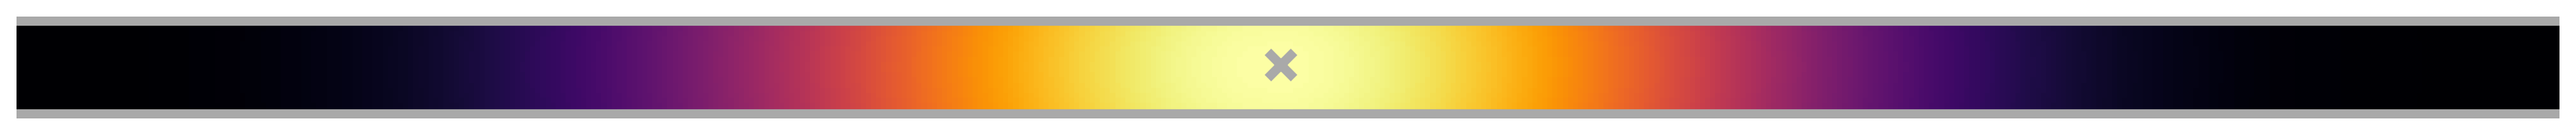

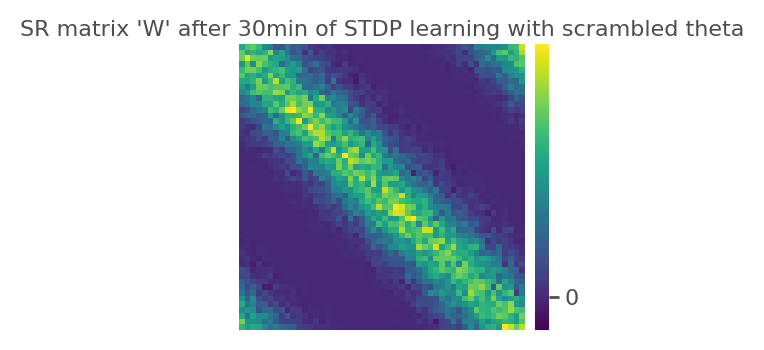

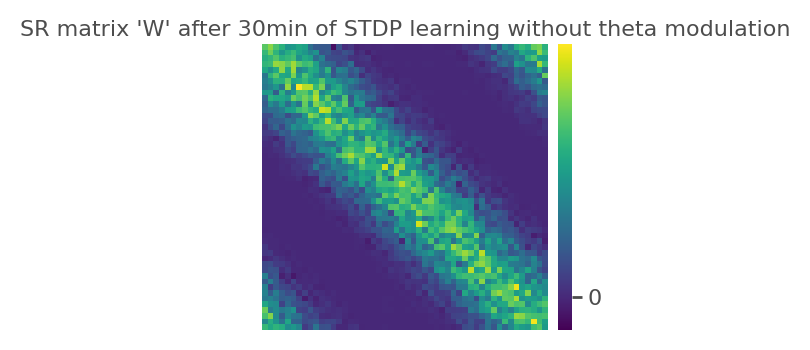

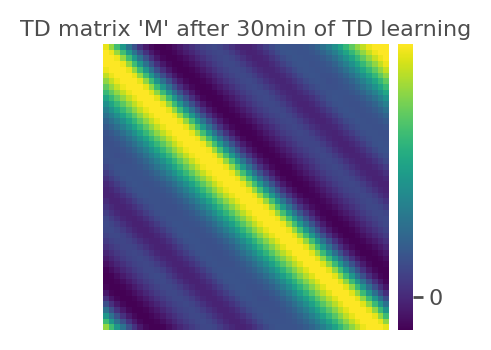

In [86]:
# Set parameters and run simulation
agent_scr.pos = np.array([0,0.1])  
agent_scr.dir = np.array([1,0]) # start at the west end of the loop, facing east, so we can follow the walls in a clockwise direction

# Define agent to train for 30min (as in paper), with STDP learning, no TD learning and save snapshots every 1min
model1= agent_scr.runRat(trainTime=30, STDPLearn=True, TDSRLearn=True, saveEvery=0.5)
model1

# Define what to plot from this STDP run
plotter = Visualiser(agent_scr) # create new plotter to access the data from the STDP run we just did

# PLOTTING
# plot STDP weight matrix 'W' with clean theta
plotter.plotM(whichM="W", colorbar=True, title="SR matrix 'W' after 30min of STDP learning", save=True)
# plot basis feature again
plotter.plotReceptiveField(25)

# plot place field of cell 25 with TD learning 
fig, ax=plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=False, threshold=0.0)
ax.set_title("Place field of cell 25 with TD learning", fontsize=12)

# plot place field of cell 25 with STDP learning (clean theta)
plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=True, no_theta=False, threshold=0.0)

# plot place field of cell 25 with STDP learning but no theta modulation 
plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=True, no_theta=True, threshold=0.0)

# scrambled that place field of cell 25 with STDP learning but no theta modulation
plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=True, no_theta=False, scrambled=True, threshold=0.0)

# Plot scrambled
plotter.plotM(whichM="W_scrambled", colorbar=True, title="SR matrix 'W' after 30min of STDP learning with scrambled theta", save=True) 

# Plot no_theta
plotter.plotM(whichM="W_notheta", colorbar=True, title="SR matrix 'W' after 30min of STDP learning without theta modulation", save=True)

# Plot TD plots
plotter.plotM(whichM="M", colorbar=True, title="TD matrix 'M' after 30min of TD learning", save=True)


# Plot combined plots 
#plotter.plotMAveraged(time=None, x_ticks=None, plot_no_theta=True, color='C7',ylim=None, renorm=True, return_data=True)
#plotter.plotMetrics(total_time=None, x_ticks=None)

R2: M-->W= 0.9883967846605431 M-->Wnotheta= 0.7865729698356743 M-->Wscrambled= 0.6126020912356227
R2: M-->W= 0.9883967846605431 M-->Wnotheta= 0.7865729698356743 M-->Wscrambled= 0.6126020912356227
R2: M-->W= 0.9883967846605431 M-->Wnotheta= 0.7865729698356743 M-->Wscrambled= 0.6126020912356227
R2: M-->W= 0.9883967846605431 M-->Wnotheta= 0.7865729698356743 M-->Wscrambled= 0.6126020912356227
R2: M-->W= 0.9883967846605431 M-->Wnotheta= 0.7865729698356743 M-->Wscrambled= 0.6126020912356227


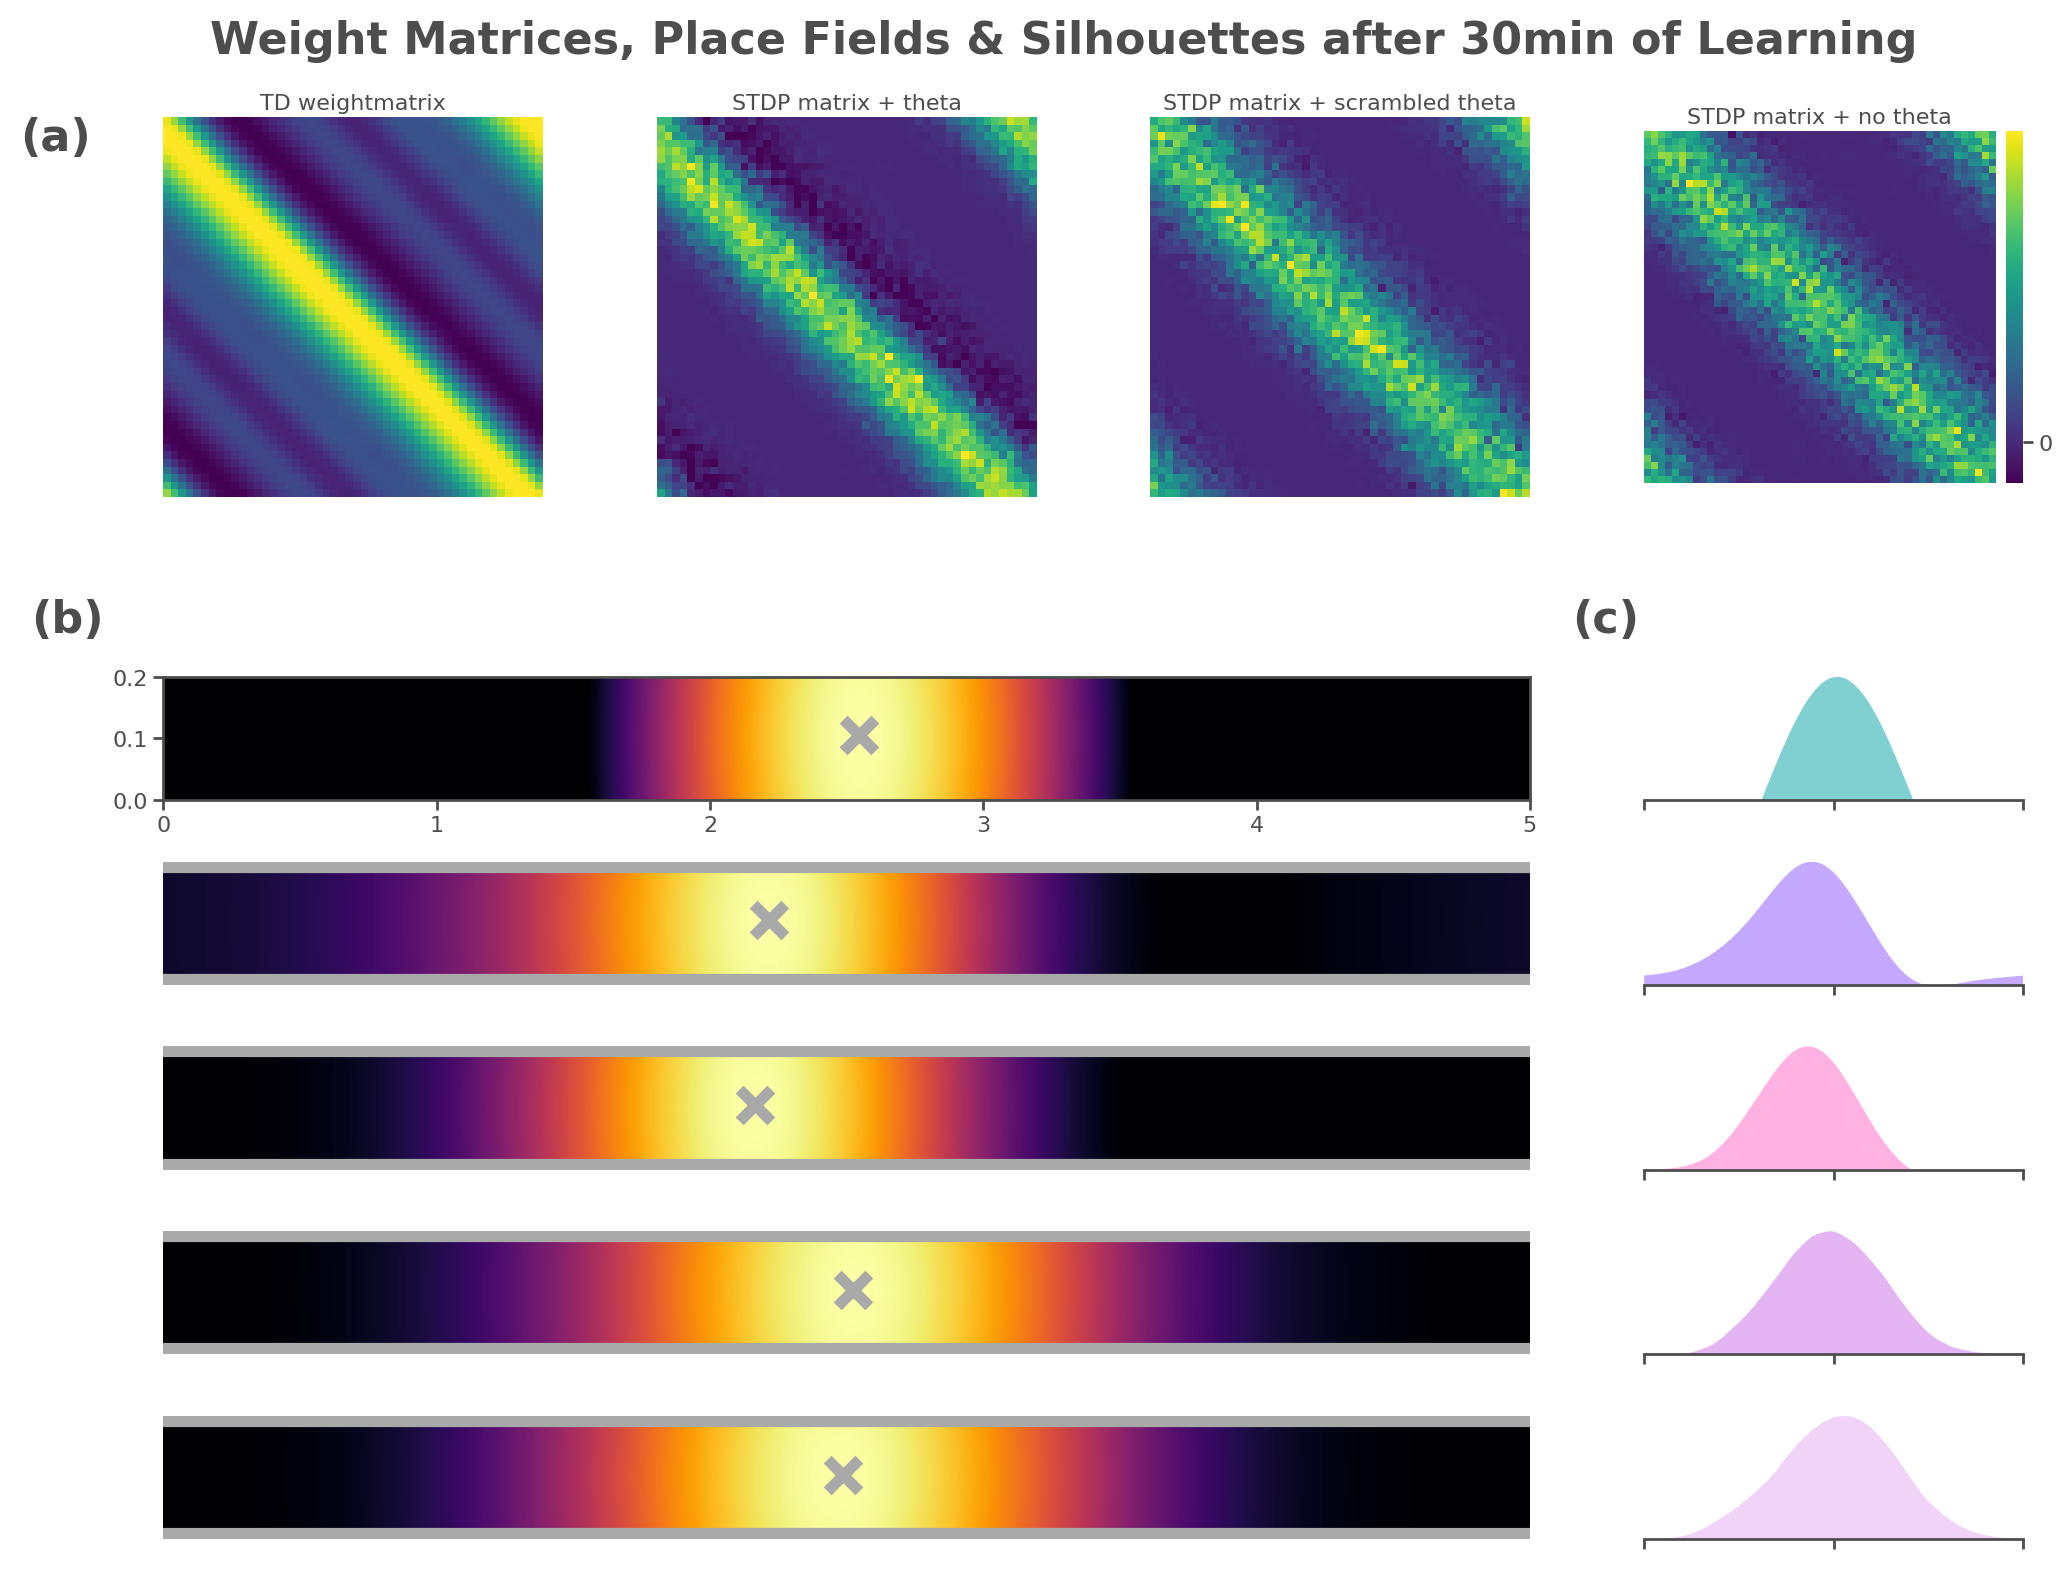

In [128]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(12, 10), constrained_layout=False)
gs = gridspec.GridSpec(6, 4, height_ratios=[2, 0.4, 0.4, 0.4, 0.4, 0.4], hspace=0.3, wspace=0.3)

# Top row: 4 square plots (row 0, columns 0-3)
ax1 = fig.add_subplot(gs[0, 0])  # Square 1
plotter.plotM(whichM="M", colorbar=False, title="TD weightmatrix", save=False, plotTimeStamp=False, fig=fig, ax=ax1)
ax2 = fig.add_subplot(gs[0, 1])  # Square 2
plotter.plotM(whichM="W", colorbar=False, title="STDP matrix + theta", save=False, fig=fig, ax=ax2)
ax3 = fig.add_subplot(gs[0, 2])  # Square 3
plotter.plotM(whichM="W_scrambled", colorbar=False, title="STDP matrix + scrambled theta", save=False, fig=fig, ax=ax3)
ax4 = fig.add_subplot(gs[0, 3])  # Square 4
plotter.plotM(whichM="W_notheta", colorbar=True, title="STDP matrix + no theta", save=False, fig=fig, ax=ax4)

# 5 wide/narrow plots below (rows 1-5, columns 0-1; twice as wide)
ax5 = fig.add_subplot(gs[1, 0:3])
plotter.plotReceptiveField(25, fig=fig, ax=ax5)
ax5.set_aspect('auto') 
ax6 = fig.add_subplot(gs[2, 0:3]) #TD place field
plotter.plotPlaceField(hist_id=-1, number=25, save=False, STDP=False, threshold=0.0, fig=fig, ax=ax6)
ax6.set_aspect('auto')
ax7 = fig.add_subplot(gs[3, 0:3]) # STDP place field with theta
plotter.plotPlaceField(hist_id=-1, number=25, save=False, STDP=True, no_theta=False, threshold=0.0, fig=fig, ax=ax7)
ax7.set_aspect('auto')
ax8 = fig.add_subplot(gs[4, 0:3]) # STDP place field without theta
plotter.plotPlaceField(hist_id=-1, number=25, save=False, STDP=True, no_theta=True, threshold=0.0, fig=fig, ax=ax8)
ax8.set_aspect('auto')
ax9 = fig.add_subplot(gs[5, 0:3]) # STDP place field with scrambled theta
plotter.plotPlaceField(hist_id=-1, number=25, save=False, STDP=True, no_theta=False, scrambled=True, threshold=0.0, fig=fig, ax=ax9)
ax9.set_aspect('auto')

# 5 shorter plots to the right (rows 1-5, column 2 only; half as wide)
ax10 = fig.add_subplot(gs[1, 3]) # RF before learning
plotter.plotFieldSilhouette(N=25, plot_pf=False, plot_pf_notheta=False, plot_pf_M=False, plot_rf=True, plot_pf_scrambled=False, no_theta=False, ax=ax10)
ax11 = fig.add_subplot(gs[2, 3]) # RF after TD learning
plotter.plotFieldSilhouette(N=25, plot_pf=False, plot_pf_notheta=False, plot_pf_M=True, plot_rf=False, plot_pf_scrambled=False, no_theta=False, ax=ax11)
ax12 = fig.add_subplot(gs[3, 3]) # RF after STDP learning with theta
plotter.plotFieldSilhouette(N=25, plot_pf=True, plot_pf_notheta=False, plot_pf_M=False, plot_rf=False, plot_pf_scrambled=False, no_theta=False, ax=ax12) # STDP with theta
ax13 = fig.add_subplot(gs[4, 3]) # RF after STDP learning without theta
plotter.plotFieldSilhouette(N=25, plot_pf=False, plot_pf_notheta=True, plot_pf_M=False, plot_rf=False, plot_pf_scrambled=False, no_theta=False, ax=ax13) # STDP without theta
ax14 = fig.add_subplot(gs[5, 3]) # RF after STDP learning with scrambled theta
plotter.plotFieldSilhouette(N=25, plot_pf=False, plot_pf_notheta=False, plot_pf_M=False, plot_rf=False, plot_pf_scrambled=True, no_theta=False, ax=ax14) # STDP with scrambled theta

# add labels
labels = ['(a)', '(b)', '(c)']
fig.suptitle('Weight Matrices, Place Fields & Silhouettes after 30min of Learning', fontsize=16, fontweight='bold', y=0.87)
# (a) - Above top row (center)
fig.text(0.08, 0.80, labels[0], fontsize=16, fontweight='bold', 
         ha='center', va='bottom', transform=fig.transFigure)

# (b) - Left of bottom-left wide plots
fig.text(0.1, 0.57, labels[1], fontsize=16, fontweight='bold', 
         ha='right', va='center', transform=fig.transFigure)

# (c) - Left of bottom-right narrow plots  
fig.text(0.74, 0.57, labels[2], fontsize=16, fontweight='bold',
         ha='right', va='center', transform=fig.transFigure)

plt.show()


### Plot Scrambled vs Clean Theta Oscillations 

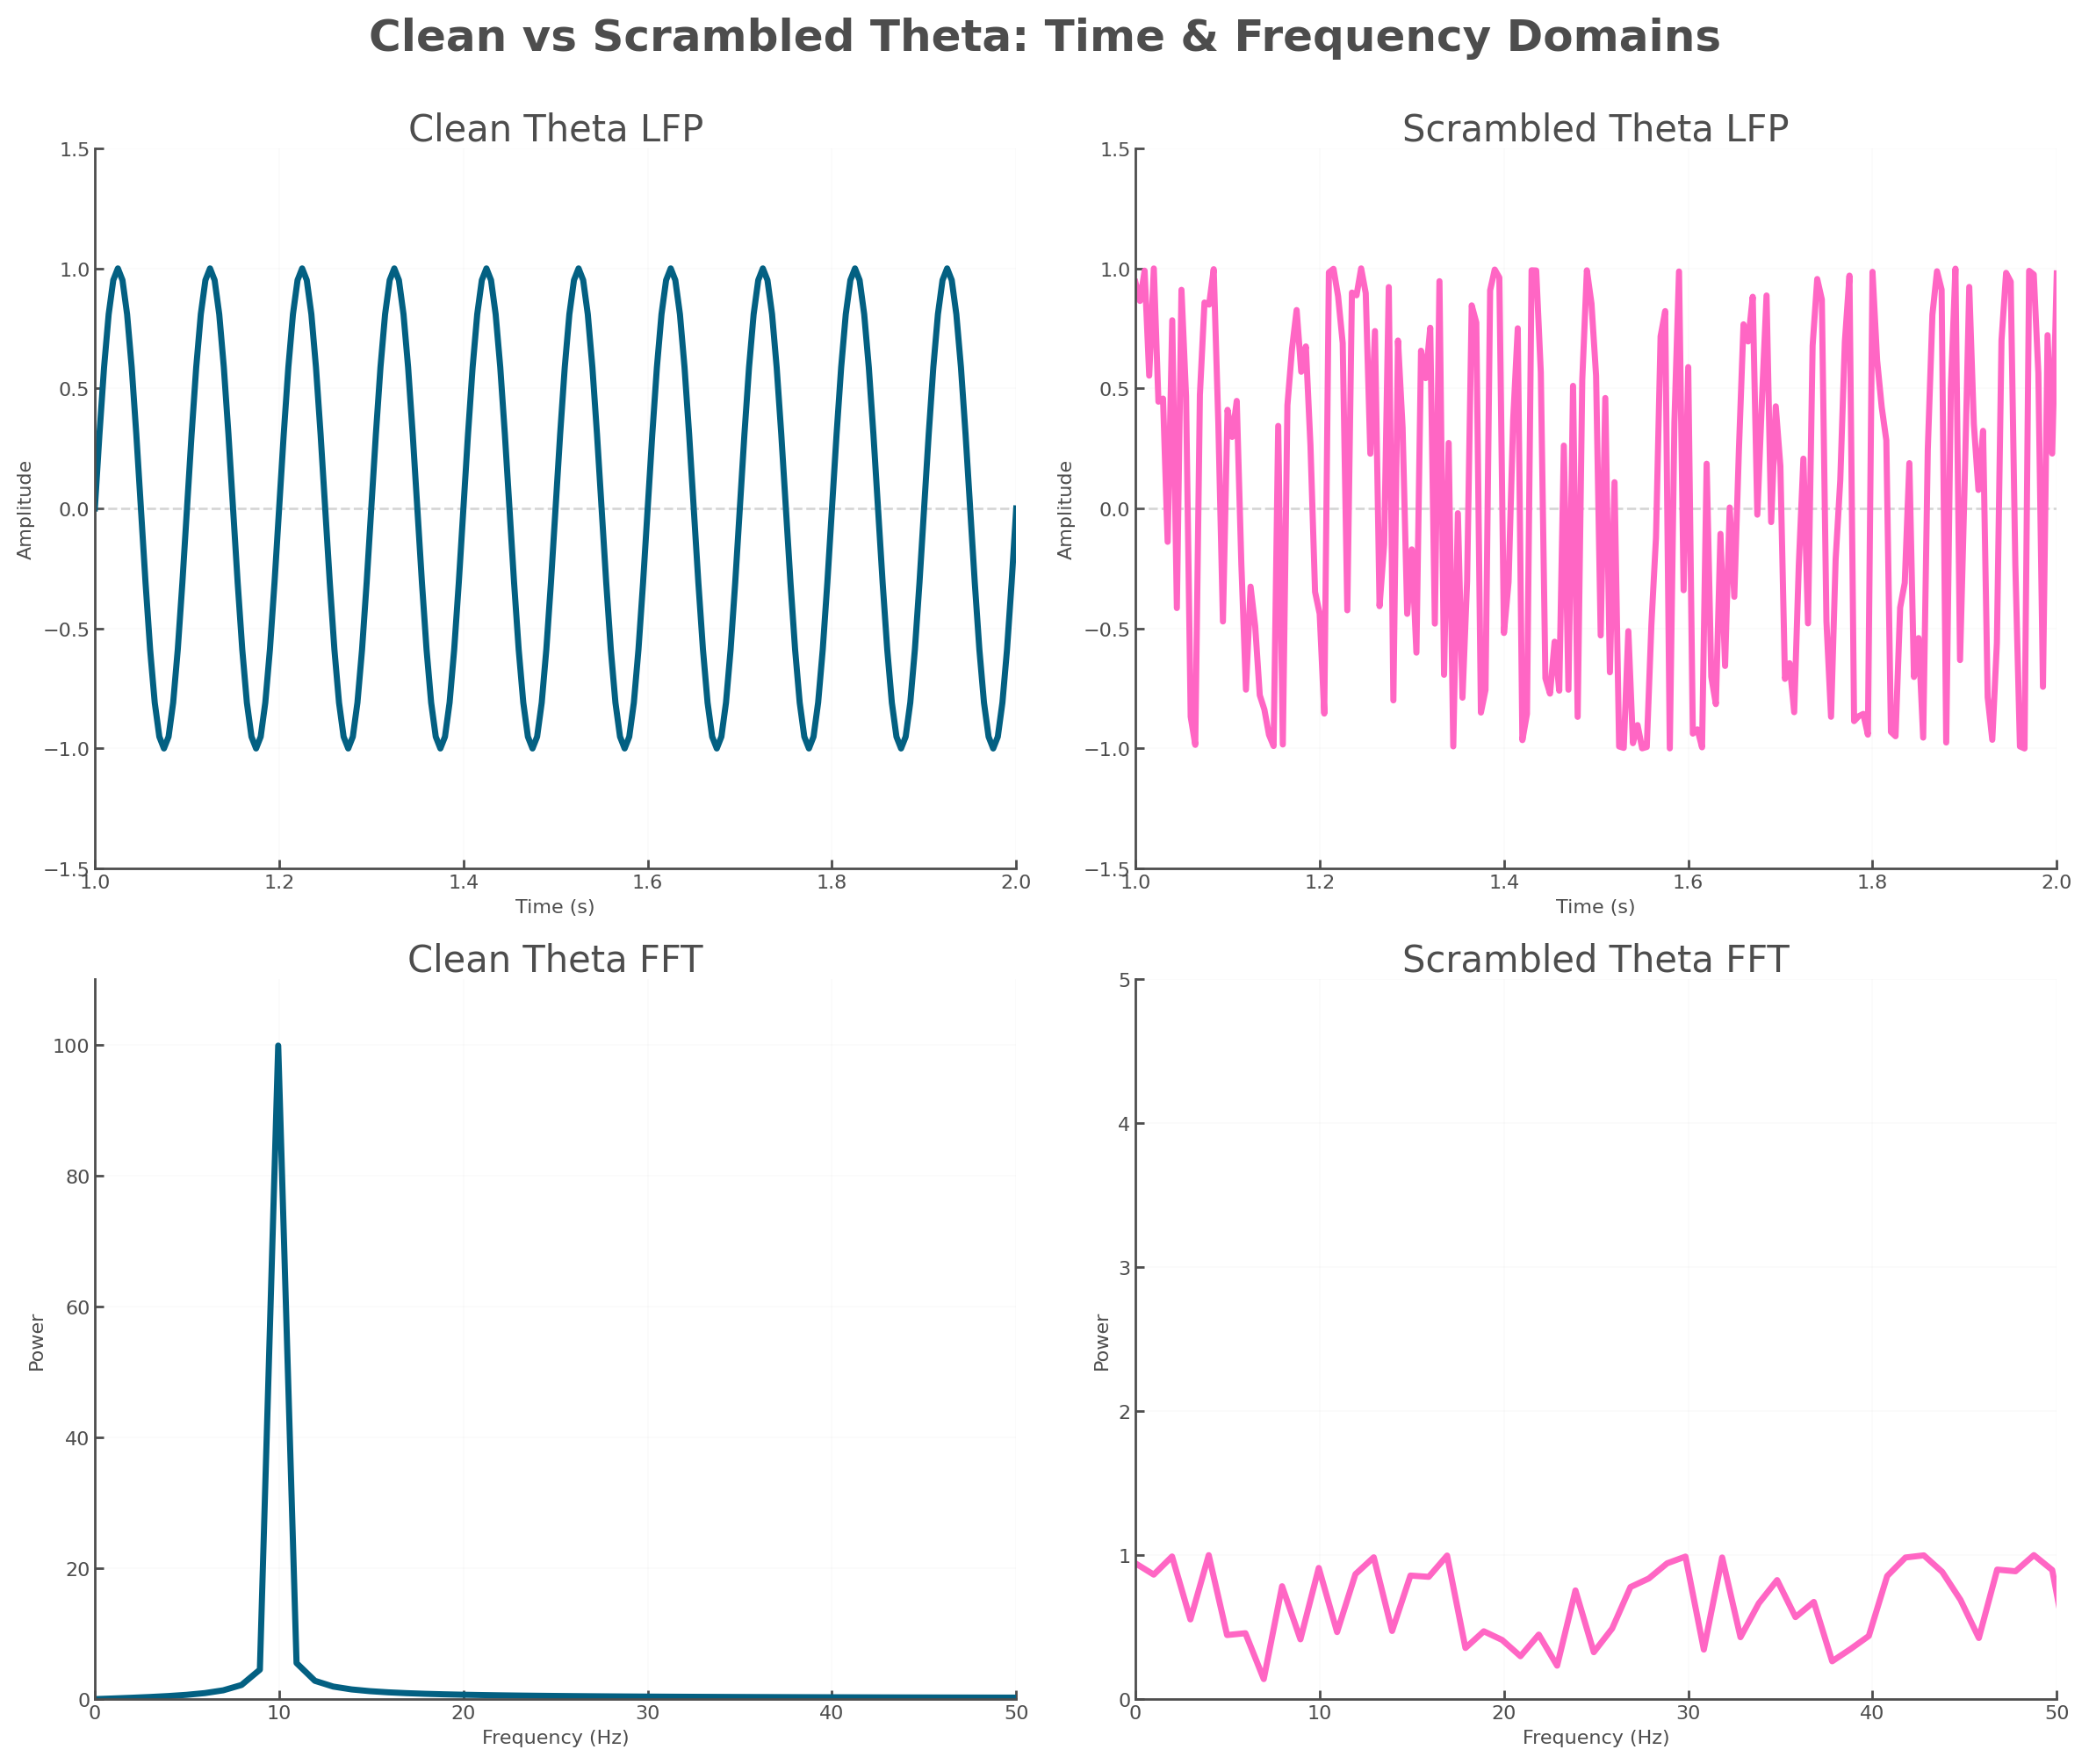

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import windows

# Your time window & data extraction
start_time = 1.0
end_time = 2.0
dt = agent_scr.dt

scrambled_phases = np.asarray(agent_scr.thetaPhase_scrambled_history, dtype=float)
scrambled_times = np.arange(len(scrambled_phases)) * dt
mask = (scrambled_times >= start_time) & (scrambled_times <= end_time)
t_window = scrambled_times[mask]
theta_scrambled_window = scrambled_phases[mask]
theta_clean_window = agent_scr.thetaFreq * (t_window % (1/agent_scr.thetaFreq)) * 2 * np.pi

# LFP signals
lfp_clean = np.sin(theta_clean_window)
lfp_scrambled = np.sin(theta_scrambled_window)

# FFT computation
N = len(t_window)
freq = fftfreq(N, dt)[:N//2]
fft_clean = np.abs(fft(lfp_clean))[:N//2]
fft_scrambled = np.abs(fft(lfp_scrambled))[:N//2]

# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='in')

# Top-left: Clean LFP
axes[0,0].axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.3)
axes[0,0].plot(t_window, lfp_clean, color='#036082', linewidth=2.5)
axes[0,0].set_title('Clean Theta LFP', fontsize= 15)
axes[0,0].set_ylabel('Amplitude')
axes[0,0].set_xlabel('Time (s)')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_xlim(start_time, end_time)
axes[0,0].set_ylim(-1.5, 1.5)

# Top-right: Scrambled LFP
axes[0,1].axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.3)
axes[0,1].plot(t_window, lfp_scrambled, color='#ff66c4', linewidth=2.5)
axes[0,1].set_title('Scrambled Theta LFP', fontsize=15)
axes[0,1].set_ylabel('Amplitude')
axes[0,1].set_xlabel('Time (s)')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_xlim(start_time, end_time)
axes[0,1].set_ylim(-1.5, 1.5)

# Bottom-left: Clean FFT
axes[1,0].plot(freq[:1000], fft_clean[:1000], color='#036082', linewidth=2.5)
axes[1,0].set_title('Clean Theta FFT', fontsize=15)
axes[1,0].set_xlabel('Frequency (Hz)')
axes[1,0].set_ylabel('Power')
axes[1,0].set_xlim(0, 50)
axes[1,0].set_ylim(0,110)
axes[1,0].grid(True, alpha=0.3)

# Bottom-right: Scrambled FFT
axes[1,1].plot(freq[:1000], fft_scrambled[:1000], color='#ff66c4', linewidth=2.5)
axes[1,1].set_title('Scrambled Theta FFT', fontsize=15)
axes[1,1].set_xlabel('Frequency (Hz)')
axes[1,1].set_ylabel('Power')
axes[1,1].set_xlim(0, 50)
axes[1,1].set_ylim(0,5)
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Clean vs Scrambled Theta: Time & Frequency Domains', fontsize=18, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()
